# Assignment 5: Bankruptcy Prediction

I created a stratified 70/15/15 train-validation-test split with random seed 42, and I will use the test set only once for the final evaluation after model selection.

## 1. Problem Definition

- Target variable: `Bankrupt?`
- Positive class: `1`
- Business context: false negatives are more costly than false positives
- Primary discrimination metric: `PR-AUC`
- Primary calibration metric: `Brier score`
- Secondary metrics: ROC-AUC, precision, recall, and F2-score at one chosen threshold

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
from xgboost import XGBClassifier

from src.model_utils import (
    RANDOM_STATE,
    compute_metrics,
    evaluate_experiment,
    find_best_threshold,
    make_scale_pos_weight,
    select_top_features,
    split_balance,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

DATA_PATH = Path("data/data.csv")
TARGET = "Bankrupt?"

df = pd.read_csv(DATA_PATH)
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256969e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897851e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.0068

## 2. Quick EDA

Keep this section short and connect observations directly to modeling choices.

Shape: (6819, 96)

Dtypes summary:
float64    93
int64       3
Name: count, dtype: int64

Missing values: 0
Duplicate rows: 0


,count,percent
Bankrupt?,,
0,6599,96.77
1,220,3.23


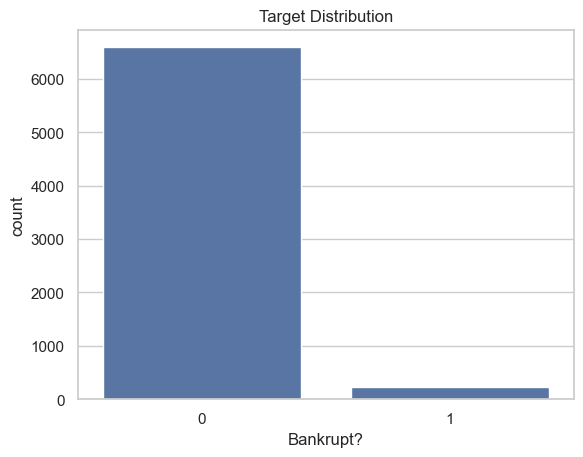

In [7]:
print("Shape:", df.shape)
print("\nDtypes summary:")
print(df.dtypes.value_counts())
print("\nMissing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

target_counts = df[TARGET].value_counts().sort_index()
target_percents = df[TARGET].value_counts(normalize=True).sort_index().mul(100)
display(pd.DataFrame({"count": target_counts, "percent": target_percents.round(2)}))

sns.countplot(data=df, x=TARGET)
plt.title("Target Distribution")
plt.show()

**Observation:** Only a small share of companies are bankrupt, so the classes are highly imbalanced and accuracy will not be my primary metric.

## 3. Train / Validation / Test Split

In [8]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

display(split_balance(y_train))
display(split_balance(y_val))
display(split_balance(y_test))

Train shape: (4773, 95)
Validation shape: (1023, 95)
Test shape: (1023, 95)


,count,percent
Bankrupt?,,
0,4619,96.77
1,154,3.23


,count,percent
Bankrupt?,,
0,990,96.77
1,33,3.23


,count,percent
Bankrupt?,,
0,990,96.77
1,33,3.23


## 4. Preprocessing

Keep preprocessing minimal. Verify whether columns are numeric or categorical, check for missing values, and only scale the model that needs scaling.

In [9]:
numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", len(numeric_columns))
print("Categorical columns:", len(categorical_columns))

logreg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_columns,
        )
    ],
    remainder="drop",
)

xgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_columns),
    ],
    remainder="drop",
)

suspected_leakage_columns = [col for col in X_train.columns if "bankrupt" in col.lower() or "target" in col.lower()]
print("Possible leakage columns:", suspected_leakage_columns)

Numeric columns: 95
Categorical columns: 0
Possible leakage columns: []


## 5. Feature Sets

In [10]:
feature_set_a = numeric_columns.copy()

xgb_selector = Pipeline([
    ("preprocessor", xgb_preprocessor),
    (
        "model",
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
        ),
    ),
])

xgb_selector.fit(X_train[feature_set_a], y_train)
feature_set_b = select_top_features(
    xgb_selector.named_steps["model"],
    feature_set_a,
    top_n=25,
)

print("Feature Set A size:", len(feature_set_a))
print("Feature Set B size:", len(feature_set_b))
feature_set_b[:10]

Feature Set A size: 95
Feature Set B size: 25


[" Net Income to Stockholder's Equity",
 ' Persistent EPS in the Last Four Seasons',
 ' Debt ratio %',
 ' Net Value Growth Rate',
 ' Borrowing dependency',
 ' Total debt/Total net worth',
 ' Continuous interest rate (after tax)',
 ' Retained Earnings to Total Assets',
 ' Quick Ratio',
 ' ROA(B) before interest and depreciation after tax']

## 6. Reusable Evaluation Function

All experiments will use the shared helper function from `src/model_utils.py` so the comparison stays consistent.

## 7. Five Experiments

In [11]:
results = []

logreg_model = Pipeline([
    ("preprocessor", logreg_preprocessor),
    (
        "model",
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    ),
])
results.append(
    evaluate_experiment(
        exp_id=1,
        model_name="Logistic Regression",
        feature_set="A",
        estimator=logreg_model,
        X_train=X_train[feature_set_a],
        y_train=y_train,
        X_val=X_val[feature_set_a],
        y_val=y_val,
        main_settings="default",
        notes="Simple baseline",
    )
)

xgb_base = Pipeline([
    ("preprocessor", xgb_preprocessor),
    (
        "model",
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
        ),
    ),
])
results.append(
    evaluate_experiment(
        exp_id=2,
        model_name="XGBoost Baseline",
        feature_set="A",
        estimator=xgb_base,
        X_train=X_train[feature_set_a],
        y_train=y_train,
        X_val=X_val[feature_set_a],
        y_val=y_val,
        main_settings="n_estimators=300, learning_rate=0.05, max_depth=4",
        notes="First serious model",
    )
)

scale_pos_weight = make_scale_pos_weight(y_train)
xgb_imbalance = Pipeline([
    ("preprocessor", xgb_preprocessor),
    (
        "model",
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            scale_pos_weight=scale_pos_weight,
        ),
    ),
])
results.append(
    evaluate_experiment(
        exp_id=3,
        model_name="XGBoost Imbalance-Aware",
        feature_set="A",
        estimator=xgb_imbalance,
        X_train=X_train[feature_set_a],
        y_train=y_train,
        X_val=X_val[feature_set_a],
        y_val=y_val,
        main_settings=f"scale_pos_weight={scale_pos_weight:.2f}",
        notes="Uses class imbalance handling",
    )
)

xgb_tuned = Pipeline([
    ("preprocessor", xgb_preprocessor),
    (
        "model",
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
        ),
    ),
])
results.append(
    evaluate_experiment(
        exp_id=4,
        model_name="XGBoost Tuned",
        feature_set="A",
        estimator=xgb_tuned,
        X_train=X_train[feature_set_a],
        y_train=y_train,
        X_val=X_val[feature_set_a],
        y_val=y_val,
        main_settings="n_estimators=500, learning_rate=0.03, max_depth=3, subsample=0.8, colsample_bytree=0.8",
        notes="Light manual tuning",
    )
)

xgb_selected = Pipeline([
    ("preprocessor", SimpleImputer(strategy="median")),
    (
        "model",
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
        ),
    ),
])
results.append(
    evaluate_experiment(
        exp_id=5,
        model_name="XGBoost Selected Features",
        feature_set="B",
        estimator=xgb_selected,
        X_train=X_train[feature_set_b],
        y_train=y_train,
        X_val=X_val[feature_set_b],
        y_val=y_val,
        main_settings="top 25 XGBoost importance features",
        notes="Simpler feature set",
    )
)

results_df = pd.DataFrame(results).sort_values("exp_id").reset_index(drop=True)
results_df

,exp_id,model,feature_set,main_settings,train_score,val_score,overfit_gap,val_precision,val_recall,val_f1,val_brier,selected_finalist,notes
0,1,Logistic Regression,A,default,0.324006,0.200000,0.124006,0.333333,0.181818,0.235294,0.031581,No,Simple baseline
1,2,XGBoost Baseline,A,"n_estimators=300, learning_rate=0.05, max_depth=4",1.000000,0.344828,0.655172,0.769231,0.303030,0.434783,0.020749,No,First serious model
2,3,XGBoost Imbalance-Aware,A,scale_pos_weight=29.99,0.988447,0.588235,0.400211,0.526316,0.606061,0.563380,0.024217,No,Uses class imbalance handling
3,4,XGBoost Tuned,A,"n_estimators=500, learning_rate=0.03, max_dept...",0.925926,0.342466,0.583460,0.714286,0.303030,0.425532,0.019230,No,Light manual tuning
4,5,XGBoost Selected Features,B,top 25 XGBoost importance features,0.947368,0.337838,0.609531,0.625000,0.303030,0.408163,0.023308,No,Simpler feature set


In [12]:
results_df[[
    "exp_id", "model", "feature_set", "train_pr_auc", "val_pr_auc",
    "overfit_gap", "val_roc_auc", "val_brier", "threshold",
    "val_precision", "val_recall", "val_f1_or_f2", "notes"
]]


,exp_id,model,feature_set,train_score,val_score,overfit_gap,val_precision,val_recall,val_f1,val_brier,notes
0,1,Logistic Regression,A,0.324006,0.200000,0.124006,0.333333,0.181818,0.235294,0.031581,Simple baseline
1,2,XGBoost Baseline,A,1.000000,0.344828,0.655172,0.769231,0.303030,0.434783,0.020749,First serious model
2,3,XGBoost Imbalance-Aware,A,0.988447,0.588235,0.400211,0.526316,0.606061,0.563380,0.024217,Uses class imbalance handling
3,4,XGBoost Tuned,A,0.925926,0.342466,0.583460,0.714286,0.303030,0.425532,0.019230,Light manual tuning
4,5,XGBoost Selected Features,B,0.947368,0.337838,0.609531,0.625000,0.303030,0.408163,0.023308,Simpler feature set


## 8. Final Model Selection

Select the winner using validation `PR-AUC`, then use validation `Brier score` to break close ties, then check overfit gap, then prefer the simpler model if scores are close.

In [8]:
results_df.sort_values(["val_pr_auc", "val_brier", "overfit_gap"], ascending=[False, True, True])

,exp_id,model,feature_set,main_settings,train_score,val_score,overfit_gap,val_precision,val_recall,val_f1,val_brier,selected_finalist,notes
2,3,XGBoost Imbalance-Aware,A,scale_pos_weight=29.99,0.988447,0.588235,0.400211,0.526316,0.606061,0.563380,0.024217,No,Uses class imbalance handling
1,2,XGBoost Baseline,A,"n_estimators=300, learning_rate=0.05, max_depth=4",1.000000,0.344828,0.655172,0.769231,0.303030,0.434783,0.020749,No,First serious model
3,4,XGBoost Tuned,A,"n_estimators=500, learning_rate=0.03, max_dept...",0.925926,0.342466,0.583460,0.714286,0.303030,0.425532,0.019230,No,Light manual tuning
4,5,XGBoost Selected Features,B,top 25 XGBoost importance features,0.947368,0.337838,0.609531,0.625000,0.303030,0.408163,0.023308,No,Simpler feature set
0,1,Logistic Regression,A,default,0.324006,0.200000,0.124006,0.333333,0.181818,0.235294,0.031581,No,Simple baseline


## 9. Final Test Evaluation

Chosen threshold: 0.1


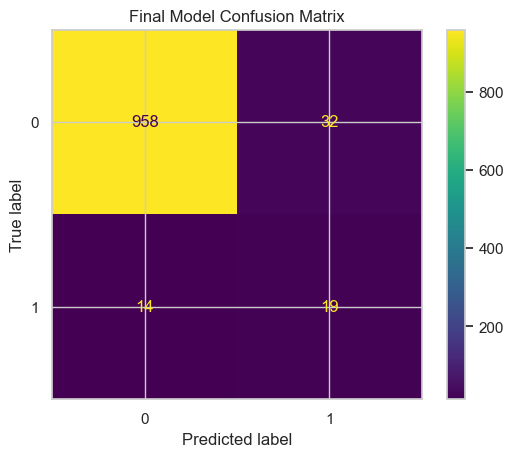

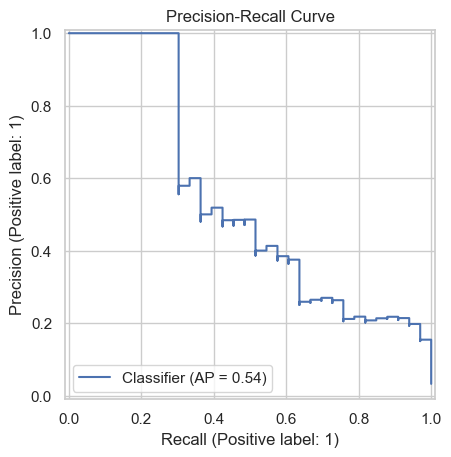

In [9]:
# Example finalist workflow. Replace `final_model` and `final_features` after choosing the winner with validation PR-AUC and Brier score.
final_model = xgb_imbalance
final_features = feature_set_a

final_model.fit(X_train[final_features], y_train)
val_proba = final_model.predict_proba(X_val[final_features])[:, 1]
threshold_result = find_best_threshold(y_val, val_proba, optimize_metric="f2")
final_threshold = threshold_result.threshold

test_proba = final_model.predict_proba(X_test[final_features])[:, 1]
test_pred = (test_proba >= final_threshold).astype(int)
test_metrics = compute_metrics(y_test, test_pred, test_proba)

print("Chosen threshold:", final_threshold)
print("Test PR-AUC:", round(test_metrics["pr_auc"], 4))
print("Test ROC-AUC:", round(test_metrics["roc_auc"], 4))
print("Test Brier score:", round(test_metrics["brier"], 4))
print("Test precision:", round(test_metrics["precision"], 4))
print("Test recall:", round(test_metrics["recall"], 4))
print("Test F2-score:", round(test_metrics["f2"], 4))

cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Final Model Confusion Matrix")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_proba)
plt.title("Precision-Recall Curve")
plt.show()

CalibrationDisplay.from_predictions(y_test, test_proba, n_bins=10)
plt.title("Calibration Curve")
plt.show()

## 10. Interpretability

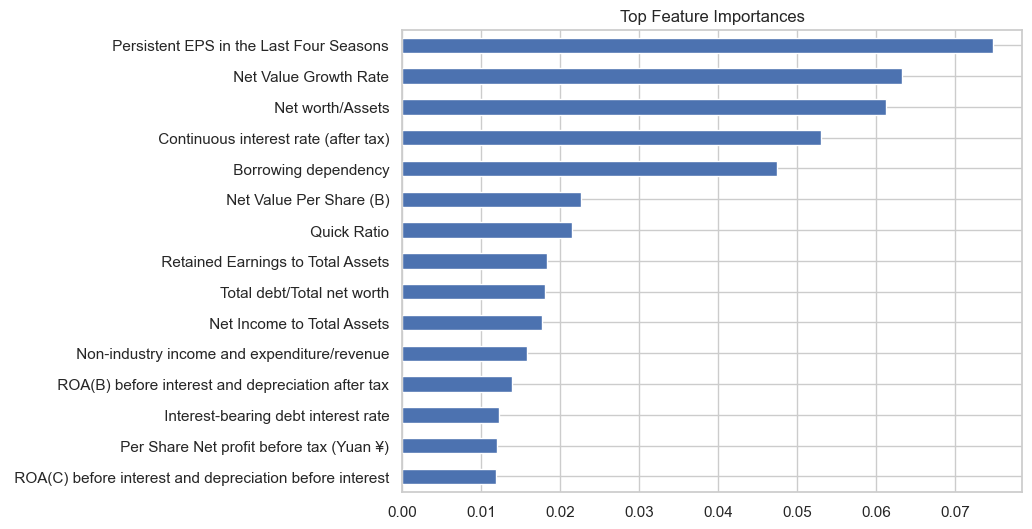

In [10]:
final_xgb = final_model.named_steps["model"]
importance = pd.Series(final_xgb.feature_importances_, index=final_features).sort_values(ascending=False).head(15)
importance.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top Feature Importances")
plt.show()

## 11. AI Usage

- AI tool used: Codex in VS Code
- What it helped with:
- What I verified or fixed myself:
- One mistake or weak suggestion I caught:

## 12. Conclusion / Short Summary

Summarize the winning model, the validation-based selection logic, the final test results, and whether the model appears overfit.